# **Libraries**

In [1]:
# Standard library
import os
import gc
import time
import math
import random
import logging
import json
import warnings
from pathlib import Path
from sympy import prod

# Scientific computing
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler

# Audio processing
import librosa
import librosa.display
import torchaudio
import torchaudio.transforms as T

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd
from IPython.display import Audio

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.parametrizations import weight_norm

# Computer vision
import cv2
import torchvision

# Miscellaneous
from tqdm import tqdm
from tqdm.auto import tqdm
import timm
import einops
from einops import rearrange

logging.basicConfig(level=logging.ERROR)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
device = "cuda" if torch.cuda.is_available() else 'gpu'

# **Akorn**

## **K_Utils**

In [3]:
def reshape(x: torch.Tensor, n: int):
    if x.ndim == 3:  # x.shape = ([B, T, C ])
        return x.transpose(1, 2).unflatten(1, (-1, n))
    else:  # x.shape = ([B, C, ..., ])
        return x.unflatten(1, (-1, n))


def reshape_back(x):
    if x.ndim == 4:  # Tokens
        return x.flatten(1, 2).transpose(1, 2)
    else:
        return x.flatten(1, 2)


def _l2normalize(x):
    return torch.nn.functional.normalize(x, dim=2)


def norm(n, x, dim=2, keepdim=True):
    return torch.linalg.norm(reshape(x, n), dim=dim, keepdim=keepdim)


def normalize(x: torch.Tensor, n):
    x = reshape(x, n)
    x = _l2normalize(x) 
    x = reshape_back(x)
    return x

# currently not used
def compute_exponential_map(n, x, dxdt, reshaped_inputs=False):
    if not reshaped_inputs:
        dxdt = reshape(dxdt, n)
        x = reshape(x, n)
    norm = torch.linalg.norm(dxdt, dim=2, keepdim=True)
    norm = torch.clip(norm, 0, math.pi)
    nx = torch.cos(norm) * x + torch.sin(norm) * (dxdt / (norm + 1e-5))
    if not reshaped_inputs:
        nx = reshape_back(nx)
    return nx


class Normalize(nn.Module):

    def __init__(self, n):
        super().__init__()
        self.n = n

    def forward(self, x):
        return normalize(self.n, x)

## **Common Layers**

In [4]:
class Interpolate(nn.Module):

    def __init__(self, r, mode="bilinear"):
        super().__init__()
        self.r = r
        self.mode = mode

    def forward(self, x):
        return F.interpolate(
            x, scale_factor=self.r, mode=self.mode, align_corners=False
        )


class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)


class ResBlock(nn.Module):

    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x):
        return x + self.fn(x)


class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H/patch_size, W/patch_size)
        x = x.flatten(2)  # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


class ReadOutConv(nn.Module):
    def __init__(
        self,
        inch,
        outch,
        out_dim,
        kernel_size=1,
        stride=1,
        padding=0,
    ):
        super().__init__()
        self.outch = outch
        self.out_dim = out_dim
        self.invconv = nn.Conv2d(
            inch,
            outch * out_dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )
        self.bias = nn.Parameter(torch.zeros(outch))

    def forward(self, x):
        x = self.invconv(x).unflatten(1, (self.outch, -1))
        x = torch.linalg.norm(x, dim=2) + self.bias[None, :, None, None]
        return x


class BNReLUConv2d(nn.Module):

    def __init__(
        self,
        inch,
        outch,
        kernel_size=1,
        stride=1,
        padding=0,
        norm=None,
        act=nn.ReLU(),
    ):
        super().__init__()
        if norm == "gn":
            norm = lambda ch: nn.GroupNorm(8, ch)
        elif norm == "bn":
            norm = lambda ch: nn.BatchNorm2d(ch)
        elif norm == None:
            norm = lambda ch: nn.Identity()
        else:
            raise NotImplementedError

        conv = nn.Conv2d(
            inch,
            outch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )

        self.fn = nn.Sequential(
            norm(inch),
            act,
            conv,
        )

    def forward(self, x):
        return self.fn(x)


class FF(nn.Module):

    def __init__(
        self,
        inch,
        outch,
        hidch=None,
        kernel_size=1,
        stride=1,
        padding=0,
        norm=None,
        act=nn.ReLU(),
    ):
        super().__init__()
        if hidch is None:
            hidch = 4 * inch
        self.fn = nn.Sequential(
            BNReLUConv2d(
                inch,
                hidch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                norm=norm,
                act=act,
            ),
            BNReLUConv2d(
                hidch,
                outch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                norm=norm,
                act=act,
            ),
        )

    def forward(self, x):
        x = self.fn(x)
        return x


class LayerNormForImage(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(1, num_features, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, num_features, 1, 1))

    def forward(self, x):
        # x shape: [B, C, H, W]
        mean = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        if x.ndim == 2:
            x_normalized = self.gamma[..., 0, 0] * x_normalized + self.beta[..., 0, 0]
        else:
            x_normalized = self.gamma * x_normalized + self.beta
        return x_normalized


class ScaleAndBias(nn.Module):
    def __init__(self, num_channels, token_input=False):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.token_input = token_input

    def forward(self, x):
        # Determine the shape for scale and bias based on input dimensions
        if self.token_input:
            # token input
            shape = [1, 1, -1]
            scale = self.scale.view(*shape)
            bias = self.bias.view(*shape)
        else:
            # image input
            shape = [1, -1] + [1] * (x.dim() - 2)
            scale = self.scale.view(*shape)
            bias = self.bias.view(*shape)
        return x * scale + bias


class RGBNormalize(nn.Module):
    def __init__(self, mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010)):
        super().__init__()

        self.mean = torch.tensor(mean).view(1, len(mean), 1, 1)
        self.std = torch.tensor(std).view(1, len(std), 1, 1)

    def forward(self, x):
        if x.device != self.mean.device:
            self.mean = self.mean.to(x.device)
            self.std = self.std.to(x.device)
        return (x - self.mean) / self.std

    def inverse(self, x):
        if x.device != self.mean.device:
            self.mean = self.mean.to(x.device)
            self.std = self.std.to(x.device)
        return (x * self.std) + self.mean


class FeatureAttention(nn.Module):
    def __init__(self, n, ch):
        super().__init__()
        self.n = n
        self.ch = ch
        self.q_linear = nn.Linear(n, n)
        self.k_linear = nn.Linear(n, n)
        self.v_linear = nn.Linear(n, n)
        self.o_linear = nn.Linear(n, n)

    def forward(self, x):
        B = x.shape[0]
        q, k, v = map(lambda x: x.view(B, -1, self.n), (x, x, x))
        q = self.q_linear(q)
        k = self.k_linear(k)
        v = self.v_linear(v)

        o = F.scaled_dot_product_attention(q, k, v)
        return self.o_linear(o).view(B, -1)


class Attention(nn.Module):
    def __init__(
        self,
        ch,
        heads=8,
        weight="conv",
        kernel_size=1,
        stride=1,
        padding=0,
        gta=False,
        rope=False,
        hw=None,
    ):
        super().__init__()

        self.heads = heads
        self.head_dim = ch // heads
        self.weight = weight
        self.stride = stride

        if weight == "conv":
            self.W_qkv = nn.Conv2d(
                ch,
                3 * ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            )
            self.W_o = nn.Conv2d(
                ch,
                ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            )
        elif weight == "fc":
            self.W_qkv = nn.Linear(ch, 3 * ch)
            self.W_o = nn.Linear(ch, ch)
        else:
            raise ValueError("weight should be 'conv' or 'fc': {}".format(weight))

        self.gta = gta
        self.rope = rope
        assert (int(self.gta) + int(self.rope)) <= 1  # either gta or rope

        self.hw = hw

        if gta or rope:
            assert hw is not None
            F = self.head_dim // 4
            if self.head_dim % 4 != 0:
                F = F + 1

            if not isinstance(hw, list):
                coord = hw
                _mat = make_SO2mats(coord, F).flatten(1, 2)  # [h*w, head_dim/2, 2, 2]
            else:
                coord = make_2dcoord(hw[0], hw[1])
                _mat = (
                    make_SO2mats(coord, F).flatten(2, 3).flatten(0, 1)
                )  # [h*w, head_dim/2, 2, 2]

            _mat = _mat[..., : self.head_dim // 2, :, :]
            # set indentity matrix for additional tokens

            if gta:
                self.mat_q = nn.Parameter(_mat)
                self.mat_k = nn.Parameter(_mat)
                self.mat_v = nn.Parameter(_mat)
                self.mat_o = nn.Parameter(_mat.transpose(-2, -1))
            elif rope:
                self.mat_q = nn.Parameter(_mat)
                self.mat_k = nn.Parameter(_mat)

    def rescale_gta_mat(self, mat, hw):
        # _mat = [h*w, head_dim/2, 2, 2]
        if hw[0] == self.hw[0] and hw[1] == self.hw[1]:
            return mat
        else:
            f, c, d = mat.shape[1:]
            mat = einops.rearrange(
                mat, "(h w) f c d -> (f c d) h w", h=self.hw[0], w=self.hw[1]
            )
            mat = F.interpolate(mat[None], size=hw, mode="bilinear")[0]
            mat = einops.rearrange(mat, "(f c d) h w -> (h w) f c d", f=f, c=c, d=d)
            return mat

    def forward(self, x):

        if self.weight == "conv":
            h, w = x.shape[2] // self.stride, x.shape[3] // self.stride
        else:
            h, w = self.hw

        reshape_str = (
            "b (c nh) h w -> b nh (h w) c"
            if self.weight == "conv"
            else "b k (c nh)  -> b nh k c"
        )
        dim = 1 if self.weight == "conv" else 2
        q, k, v = self.W_qkv(x).chunk(3, dim=dim)
        q, k, v = map(
            lambda x: einops.rearrange(x, reshape_str, nh=self.heads),
            (q, k, v),
        )
        if self.gta:
            q, k, v = map(
                lambda args: rep_mul_x(self.rescale_gta_mat(args[0], (h, w)), args[1]),
                ((self.mat_q, q), (self.mat_k, k), (self.mat_v, v)),
            )
        elif self.rope:
            q, k = map(
                lambda args: rep_mul_x(args[0], args[1]),
                ((self.mat_q, q), (self.mat_k, k)),
            )

        x = torch.nn.functional.scaled_dot_product_attention(
            q, k, v, attn_mask=self.mask if hasattr(self, "mask") else None
        )

        if self.gta:
            x = rep_mul_x(self.rescale_gta_mat(self.mat_o, (h, w)), x)

        if self.weight == "conv":
            x = einops.rearrange(x, "b nh (h w) c -> b (c nh) h w", h=h, w=w)
        else:
            x = einops.rearrange(x, "b nh k c -> b k (c nh)")

        x = self.W_o(x)

        return x

## **GTA**

In [5]:
def make_2dcoord(H, W, normalize=False):
    """
    Return(torch.Tensor): 2d coord values of shape [H, W, 2]
    """
    x = np.arange(H, dtype=np.float32)  # [0, H)
    y = np.arange(W, dtype=np.float32)  # [0, W)
    if normalize:
        x = x / H
        y = y / W
    x_grid, y_grid = np.meshgrid(x, y, indexing="ij")
    return torch.Tensor(
        np.stack([x_grid.flatten(), y_grid.flatten()], -1).reshape(H, W, 2)
    )


def make_SO2mats(coord, nfreqs):
    """
    Args:
    coord: [..., 2 or 3]
    freqs: [n_freqs, 2 or 3]
    Return:
    mats of shape [..., n_freqs, (2 or 3), 2, 2]
    """
    dim = coord.shape[-1]
    b = 10000.0
    freqs = torch.exp(torch.arange(0.0, 2 * nfreqs, 2) * -(math.log(b) / (2 * nfreqs)))
    grid_ths = [
        torch.einsum("...i,j->...ij", coord[..., d : d + 1], freqs).flatten(-2, -1)
        for d in range(dim)
    ]

    _mats = [
        [
            torch.cos(grid_ths[d]),
            -torch.sin(grid_ths[d]),
            torch.sin(grid_ths[d]),
            torch.cos(grid_ths[d]),
        ]
        for d in range(dim)
    ]
    mats = [
        rearrange(torch.stack(_mats[d], -1), "... (h w)->... h w", h=2, w=2)
        for d in range(dim)
    ]
    mat = torch.stack(mats, -3)
    return mat


# GTA
@torch.jit.script
def rep_mul_x(rep, x):
    #  rep.shape=[T, F, 2, 2], x.shape=[B, H, T, F*2]
    shape = x.shape
    d = rep.shape[-1]
    return (
        (rep[None, None] * (x.unflatten(-1, (-1, d))[..., None, :])).sum(-1).view(shape)
    )


@torch.jit.script
def rep_mul_qkv(rep, q, k, v):
    return rep_mul_x(rep, q), rep_mul_x(rep, k), rep_mul_x(rep, v)


@torch.jit.script
def rep_mul_qk(rep, q, k):
    return rep_mul_x(rep, q), rep_mul_x(rep, k)


def embed_block_diagonal(M, n):
    """
    Embed a [h*w, d/2, 2, 2] tensor M into a [h*w, d//2n, 4, 4] tensor M'
    with block diagonal structure.

    Args:
    M (torch.Tensor): Tensor of shape [h*w, d/2, 2, 2]
    n (int): Number of blocks to embed into 2nx2n structure

    Returns:
        torch.Tensor: Tensor of shape [h*w, d//2n, 4, 4]
    """
    h_w, d_half, _, _ = M.shape

    # Initialize an empty tensor for the block diagonal tensor M'
    M_prime = torch.zeros((h_w, d_half // n, 4, 4))

    # Embed M into the block diagonal structure of M_prime
    for t in range(h_w):
        for d in range(d_half // n):
            M_prime[t, d] = torch.block_diag(*[M[t, n * d + i] for i in range(n)])
    print(M_prime.shape)
    return M_prime

## **Common_FNs**

In [6]:
def positionalencoding2d(d_model, height, width):
    """
    :param d_model: dimension of the model
    :param height: height of the positions
    :param width: width of the positions
    :return: d_model*height*width position matrix
    """
    if d_model % 4 != 0:
        raise ValueError("Cannot use sin/cos positional encoding with "
                         "odd dimension (got dim={:d})".format(d_model))
    pe = torch.zeros(d_model, height, width)
    # Each dimension use half of d_model
    d_model = int(d_model / 2)
    div_term = torch.exp(torch.arange(0., d_model, 2) *
                         -(math.log(10000.0) / d_model))
    pos_w = torch.arange(0., width).unsqueeze(1)
    pos_h = torch.arange(0., height).unsqueeze(1)
    pe[0:d_model:2, :, :] = torch.sin(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[1:d_model:2, :, :] = torch.cos(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[d_model::2, :, :] = torch.sin(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
    pe[d_model + 1::2, :, :] = torch.cos(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)

    return pe

## **OmegaLayer**

In [7]:
class OmegaLayer(nn.Module):

    def __init__(self, n, ch, init_omg=0.1, global_omg=False, learn_omg=True):
        super().__init__()
        self.n = n
        self.ch = ch
        self.global_omg = global_omg

        if not learn_omg:
            print("Not learning omega")

        if n % 2 != 0:
            # n is odd
            raise NotImplementedError
        else:
            # n is even
            if global_omg:
                self.omg_param = nn.Parameter(
                    init_omg * (1 / np.sqrt(2)) * torch.ones(2), requires_grad=learn_omg
                )
            else:
                self.omg_param = nn.Parameter(
                    init_omg * (1 / np.sqrt(2)) * torch.ones(ch // 2, 2),
                    requires_grad=learn_omg,
                )

    def forward(self, x):
        _x = reshape(x, 2)
        if self.global_omg:
            omg = torch.linalg.norm(self.omg_param).repeat(_x.shape[1])
        else:
            omg = torch.linalg.norm(self.omg_param, dim=1)
        omg = omg[None]
        for _ in range(_x.ndim - 3):
            omg = omg.unsqueeze(-1)
        omg_x = torch.stack([omg * _x[:, :, 1], -omg * _x[:, :, 0]], dim=2)
        omg_x = reshape_back(omg_x)
        return omg_x

## **KLayer**

In [8]:
class KLayer(nn.Module):  # Kuramoto layer

    def __init__(
        self,
        n,
        ch,
        J="conv",
        c_norm="gn",
        use_omega=False,
        init_omg=1.0,
        ksize=3,
        gta=False,
        hw=None,
        global_omg=False,
        heads=8,
        learn_omg=True,
        apply_proj=True,
    ):
        # connnectivity is either 'conv' or 'ca'
        super().__init__()
        assert (ch % n) == 0
        self.n = n
        self.ch = ch
        self.use_omega = use_omega
        self.global_omg = global_omg
        self.apply_proj = apply_proj

        self.omg = (
            OmegaLayer(n, ch, init_omg, global_omg, learn_omg)
            if self.use_omega
            else nn.Identity()
        )

        if J == "conv":
            self.connectivity = nn.Conv2d(ch, ch, ksize, 1, ksize // 2)
            self.x_type = "image"
        elif J == "attn":
            self.connectivity = Attention(
                ch,
                heads=heads,
                weight="conv",
                kernel_size=1,
                stride=1,
                padding=0,
                gta=gta,
                hw=hw,
            )
            self.x_type = "image"
        else:
            raise NotImplementedError

        if c_norm == "gn":
            self.c_norm = nn.GroupNorm(ch // n, ch, affine=True)
        elif c_norm == "sandb":
            self.c_norm = ScaleAndBias(ch, token_input=False)
        elif c_norm is None or c_norm == "none":
            self.c_norm = nn.Identity()
        else:
            raise NotImplementedError

    def project(self, y, x):
        sim = x * y  # similarity between update and current state
        yxx = torch.sum(sim, 2, keepdim=True) * x
        return y - yxx, sim

    def kupdate(self, x: torch.Tensor, c: torch.Tensor = None):
        # compute  \sum_j[J_ij x_j]
        _y = self.connectivity(x)
        # add bias c.
        y = _y + c

        if hasattr(self, "omg"):
            omg_x = self.omg(x)
        else:
            omg_x = torch.zeros_like(x)

        y = reshape(y, self.n)
        x = reshape(x, self.n)

        # project y onto the tangent space
        if self.apply_proj:
            y_yxx, sim = self.project(y, x)
        else:
            y_yxx = y
            sim = y * x

        dxdt = omg_x + reshape_back(y_yxx)
        sim = reshape_back(sim)

        return dxdt, sim

    def forward(self, x: torch.Tensor, c: torch.Tensor, T: int, gamma):
        # x.shape = c.shape = [B, C,...] or [B, T, C]
        xs, es = [], []
        c = self.c_norm(c)
        x = normalize(x, self.n)
        es.append(torch.zeros(x.shape[0]).to(x.device))
        # Iterate kuramoto update with condition c
        for t in range(T):
            dxdt, _sim = self.kupdate(x, c)
            x = normalize(x + gamma * dxdt, self.n)
            xs.append(x)
            es.append((-_sim).reshape(x.shape[0], -1).sum(-1))

        return xs, es

# **Model**

In [9]:
img = torch.randn([1, 3, 256, 256], dtype = torch.float32)
img = img.to(device)

In [10]:
class UNetOscillatoryNeuron(nn.Module):

    def __init__(
        self,
        n=4, # Number of Groups
        ch=32, # Hidden Size
        L=1, # Number of Kuramoto Layers
        T=8, # Number of Kuramoto Loops per Kuramoto Layer
        psize=4, # Patch Size
        gta=True, # Global something Attention
        J="attn", # Connectivity Matrix
        ksize=1, # Kernel Size
        c_norm="gn", # Normalization for Stimuli/c
        gamma=1.0, # Gamma/dx Normalization
        imsize=256, # Input Image Size
        use_omega=True,
        init_omg=1.0,
        global_omg=False,
        maxpool=True,
        project=True,
        heads=2,
        use_ro_x=True, # Use readout
        learn_omg=True,
        no_ro=False, # Don't use readout
        autorescale=True, # Rescale Image
        debug_mode = False,
        depth = 6
    ):
        super().__init__()
        self.T = T
        self.L = L
        self.n = n
        self.ch = ch
        self.psize = psize
        self.gta = gta
        self.J = J
        self.ksize = ksize
        self.c_norm = c_norm
        self.gamma = torch.nn.Parameter(torch.Tensor([gamma]), requires_grad=False)
        self.imsize = imsize
        self.use_omega = use_omega
        self.init_omg = init_omg
        self.global_omg = global_omg
        self.maxpool = maxpool
        self.project = project
        self.heads = heads
        self.use_ro_x = use_ro_x
        self.learn_omg = learn_omg
        self.no_ro = False
        self.autorescale = autorescale
        self.fixed_ptb = False
        self.debug_mode = debug_mode
        self.depth = depth
        if self.debug_mode:
            print(f"Model is currently in Debugging Mode...")
            print(f"-"*59)
            
        self.patchfy = nn.Sequential(
            RGBNormalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            nn.Conv2d(3, self.ch, kernel_size=psize, stride=psize, padding=0) # Read Documentation to calculate Height and Width
        )

        if not gta:
            self.pos_enc = True
            self.pemb_x = nn.Parameter(
                positionalencoding2d(ch, imsize // psize, imsize // psize).reshape(
                    -1, imsize // psize, imsize // psize
                )
            )
            self.pemb_c = nn.Parameter(
                positionalencoding2d(ch, imsize // psize, imsize // psize).reshape(
                    -1, imsize // psize, imsize // psize
                )
            )
        else:
            self.pos_enc = False

        self.AkornLayersEncode, self.T_AkornLayersEncode, self.DownLayersEncode = self.encoder(depth=self.depth)
        self.AkornLayersDecode, self.T_AkornLayersDecode, self.UpLayersDecode = self.decoder(depth=self.depth)

        self.unpatchfy = nn.Sequential(
            nn.ConvTranspose2d(self.ch, 3, kernel_size = psize, stride=psize, padding=0),
            RGBNormalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        )
        
    def createAkornLayers(self, n, ch, num_layers):
        """
        Input:
            n -> int: Number of Groups for Intrinsic Frequency/Omega
            ch -> int: Similar to "Hidden State"
            num_layers -> int: Similar to L, the number of AkornLayers
            
        Return:
            AkornLayers -> list -> list: Store all of the AkornLayers
            T_AkornLayer: Store all of the Loops for AkornLayer to pass to feature()
        """
        
        feature_hw = self.imsize // self.psize
        feature_hws = [feature_hw] * num_layers
        
        if isinstance(self.T, int):
            T_AkornLayer = [self.T] * num_layers
        else:
            T_AkornLayer = self.T

        if isinstance(self.J, str):
            J_l = [self.J] * num_layers
        else:
            J_l = self.J

        chs = [ch] * (num_layers + 1)
        
        AkornLayers = nn.ModuleList()

        # Create num_layers of Akorn Layers
        for i in range(num_layers):
            ch_i = chs[i]
            if i == num_layers - 1:
                ch_nx = chs[i+1]
            else:
                ch_nx = chs[i+1]
                
            klayer = KLayer(
                n=self.n,
                ch=ch,
                J=J_l[i],
                gta=self.gta,
                c_norm=self.c_norm,
                use_omega=self.use_omega,
                init_omg=self.init_omg,
                global_omg=self.global_omg,
                heads=self.heads,
                learn_omg=self.learn_omg,
                ksize=self.ksize,
                hw=[feature_hws[i], feature_hws[i]],
                apply_proj=self.project,
            )
            
            readout = (
                ReadOutConv(ch_i, ch_nx, n, 1, 1, 0)
                if not self.no_ro
                else nn.Identity()
            )
            linear_x = (
                nn.Conv2d(ch_i, ch_nx, 1, 1, 0)
                if self.use_ro_x and i < num_layers - 1
                else nn.Identity()
            )
            AkornLayers.append(nn.ModuleList([klayer, readout, linear_x]))  

        return AkornLayers, T_AkornLayer
        
    def feature(self, stimuli, oscillators, T_f, AkornLayer):
        """
        Input:
            stimuli/c -> tensor: Stimuli/c to input to KLayer
            Oscillators/x -> tensor: Oscillator/x to input to KLayer
            T_f -> int: Number of Loops for KLayer in AkornLayer
            AkornLayer -> list: Akorn Layer
            
        Return:
            c -> tensor: The Latest Generated Stimuli
            x -> tensor: The Latest Updated Oscillator
            
            xs -> list -> list: Store all of the States of Oscillator (The iterative update T in KLayer)
            es -> list -> list: Store all of the es (The iterative update T in KLayer)
            
            new_xs -> list -> tensor: Store all of the Oscillator that has passed through lin_x
            new_stimulis -> list -> tensor: Store all of the Stimuli Generated
        """
        
        c = stimuli
        x = oscillators
        new_xs = []
        new_stimulis = []
        
        xs = [x]
        es = [torch.zeros(x.shape[0], device=x.device)]
        
        # Loop through all Akorn Layers and its Blocks.
        for l, (kblock, ro, lin_x) in enumerate(AkornLayer):
            _xs, _es = kblock(x, c, T=T_f[l], gamma=self.gamma)
            
            x = _xs[-1] # Take the Last State of Oscillator
            
            c = ro(x) # Generate new Stimuli
            new_stimulis.append(c)
            
            x = lin_x(x)
            new_xs.append(x)
            
            if self.debug_mode:
                print(f"Stimuli/c Shape after passing through #{l + 1} Readout: {c.shape}")
                print(f"Oscillator/x Shape after passing through #{l + 1} Kuramoto Layer and Linear_x: {x.shape}")
                
                
            xs.append(_xs)
            es.append(_es)

        return c, x, xs, es, new_xs, new_stimulis

    def encoder(self, depth):
        """
        Input:
            depth: Depth of the Encoder
                    Starting Input: [B, ch, 64, 64] = [B, ch, 2^{6}, 2^{6}] || [B, ch, H, W]
                    
            1. [B, self.ch, 64, 64] goes through 1st AkornLayers -> [B, ch, self.ch, self.ch]
            2. [B, self.ch, 64, 64] goes through MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                            -> [B, ch*2, 32, 32]
                    {1}
            ...
                [B, self.ch*2, 32, 32] goes through 2nd AkornLayers
                [B, self.ch*2*2, 16, 16] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                    {2}
            ...
                [B, self.ch*2*2, 16, 16] goes through 3rd AkornLayers
                [B, self.ch*8, 8, 8] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                    {3}
            ...
                [B, self.ch*8, 8, 8] goes through 4th AkornLayers
                [B, self.ch*16, 4, 4] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                    {4}
            ...
                [B, self.ch*16, 4, 4] goes through 5thAkornLayers
                [B, self.ch*32, 2, 2] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                    {5}
            ...
                [B, self.ch*32, 2, 2] goes through 6h AkornLayers
                [B, self.ch*64, 1, 1] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                    {6}
            -----> [B, self.ch*(2**(i+1)), H/(2**(i+1)), W/(2**(i+1))]
        Return:
            AkornLayersEncode -> dict -> list: Contains AkornLayer_{i -> depth}
            T_AkornLayersEncode -> dict -> list: Contains the Number of Loops to input in feature()
            DownLayersEncode -> dict -> list: Contains lists of MaxPool2d(2) and nn.Conv2d(self.ch*(i+1), ch*(2**(i+1)), 3, 1, 1)])
        """
        AkornLayers = nn.ModuleDict()
        T_AkornLayers = dict()
        DownLayers = nn.ModuleDict()
        for i in range (depth):
            in_ch = self.ch * (2 ** i) 
            out_ch = self.ch * (2 ** (i + 1))
            
            AkornLayers[f"AkornLayer_{i+1}"], T_AkornLayers[f"T_AkornLayers_{i+1}"] = self.createAkornLayers(n = self.n, ch=in_ch, num_layers = 2)
            DownLayers[f"Downsample_{i+1}"] = nn.ModuleList([nn.MaxPool2d(2), nn.Conv2d(in_ch, out_ch, 3, 1, 1)])
        return AkornLayers, T_AkornLayers, DownLayers

    
    def decoder(self, depth):
        """
        Input:
            depth: Depth of the Decoder
                    Starting Input: [B, self.ch*(2**depth), 1, 1] || [B, self.ch*(2**depth), H/(2**(depth)), W/(2**(depth))]

            1. [B, self.ch*(2**depth), 1, 1] goes through UpsamplingBilinear2d(scale_factor = 2), nn.Conv2d(in_ch, out_ch, 3, 1, 1)
                            -> [B, self.ch*(2**depth)/2, 2, 2]
            2. [B, self.ch*(2**depth)/2, 2, 2] goes through 1st AkornLayers -> Output [B, self.ch*(2**depth)/2), 2, 2]
                    {1}
            ...
            Input: [B, self.ch*(2**depth)/2, 2, 2]
            
                [B, self.ch*(2**depth)/4, 4, 4] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                [B, self.ch*(2**depth)/4, 4, 4] goes through 2nd AkornLayers
                    {2}
            ...
            Input: [B, self.ch*(2**depth)/4, 4, 4]

                [B, self.ch*(2**depth)/8, 8, 8] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                [B, self.ch*(2**depth)/8, 8, 8] goes through 3rd AkornLayers
                    {3}
            ...
            Input: [B, self.ch*(2**depth)/8, 8, 8]
            
                [B, self.ch*(2**depth)/16, 16, 16] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                [B, self.ch*(2**depth)/16, 16, 16] goes through 4th AkornLayers
                    {4}
            ...
            Input: [B, self.ch*(2**depth)/16, 16, 16]
            
                [B, self.ch*(2**depth)/32, 32, 32] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                [B, self.ch*(2**depth)/32, 32, 32] goes through 5thAkornLayers
                    {5}
            ...
            Input: [B, self.ch*(2**depth)/32, 32, 32]
            
                [B, self.ch*(2**depth)/64, 64, 64] Resultant Shape after MaxPool2d(2) and nn.Conv2d(ch, ch*2)
                [B, self.ch*(2**depth)/64, 64, 64] goes through 5thAkornLayers
                    {6}
            -----> [B, self.ch*(2**depth)/(i+1), H*(2**(i+1)), W*(2**(i+1))]
        Return:
            AkornLayersDecode -> dict -> list: Contains AkornLayer_{i -> depth}
            T_AkornLayersDecode -> dict -> list: Contains the Number of Loops to input in feature()
            DownLayersDecode -> dict -> list: Contains lists of UpsamplingBilinear2d(scale_factor = 2), 
                                                                Conv2d(self.ch*(2**self.depth), self.ch*(2**self.depth) // (2 ** (i + 1)), 3, 1, 1),
                                                                nn.BatchNorm2d(self.ch*(2**self.depth) // (2 ** (i + 1))),
                                                                nn.ReLU()
                                                                
        Note: Because this is fundamentally different from UNet and other Segmentation model,
                                                        the Skip Connection will be Addition and not Concatnation.
                            We give the oscillators information not creating/adding more oscillators 
        """
        
        AkornLayers = nn.ModuleDict() 
        T_AkornLayers = dict()
        UpLayers = nn.ModuleDict()
        for i in range (depth):
            if i == 0:
                in_ch = self.ch*(2**self.depth)
            else:
                in_ch = self.ch*(2**self.depth) // (2 ** i)
                
            out_ch = self.ch*(2**self.depth) // (2 ** (i + 1))
            
            AkornLayers[f"AkornLayer_{i+1}"], T_AkornLayers[f"T_AkornLayers_{i+1}"] = self.createAkornLayers(n = self.n, ch=in_ch, num_layers = 2)
            UpLayers[f"Upsample_{i+1}"] = nn.ModuleList([nn.UpsamplingBilinear2d(scale_factor = 2),
                                                         nn.Conv2d(in_ch, out_ch, 3, 1, 1),
                                                         nn.BatchNorm2d(out_ch),
                                                         nn.ReLU()])
        return AkornLayers, T_AkornLayers, UpLayers

    
    def forward(self, inp):
        if self.autorescale and (
            inp.shape[2] != self.imsize or inp.shape[3] != self.imsize
        ):
            inp = F.interpolate(
                inp,
                (self.imsize, self.imsize),
                mode="bilinear",
            )
            
        c = self.patchfy(inp)
        
        past_oscillators = dict()
        past_stimulis = dict()
        
        if self.fixed_ptb:
            g = torch.Generator(device="cpu").manual_seed(1234)
            x = torch.randn(*(c.shape), generator=g).to(c.device)
        else:
            x = torch.randn_like(c)

        if self.pos_enc:
            c = c + self.pemb_c[None]
            x = x + self.pemb_x[None]
        
        if self.debug_mode:
            print(f"Input Shape: {inp.shape}") # [B, 3, 256, 256]
            print(f"Stimuli/c Shape: {c.shape}") # [B, 256, 64, 64]
            print(f"Oscillators/x Shape: {x.shape}") # [B, 256, 64, 64]
            
        for i in range(len(self.AkornLayersEncode)):
            if self.debug_mode:
                print(f"Initiating Encoding Sequence {i+1}...")
                print(f" ")
                
            if (i+1) == 1:
                c_f, x_f, xs, es, new_xs, new_stimulis = self.feature(stimuli = c, oscillators = x,
                                                                      T_f = self.T_AkornLayersEncode[f"T_AkornLayers_{i+1}"],
                                                                      AkornLayer = self.AkornLayersEncode[f"AkornLayer_{i+1}"])
                past_oscillators[f"EncoderLayer_{i+1}"] = x_f
                past_stimulis[f"EncoderLayer_{i+1}"] = c_f

                pool, conv2d = self.DownLayersEncode[f"Downsample_{i+1}"]

                c_f = pool(c_f)
                c_f = conv2d(c_f)
               
                x_f = pool(x_f)
                x_f = conv2d(x_f)

                if self.debug_mode:
                    print(f"Stimuli/c Shape: {c_f.shape}")
                    print(f"Oscillators/x Shape: {x_f.shape}")
                    print("-"*59)
                
            else:
                
                c_f, x_f, xs, es, new_xs, new_stimulis = self.feature(stimuli = c_f, oscillators = x_f,
                                                                  T_f = self.T_AkornLayersEncode[f"T_AkornLayers_{i+1}"],
                                                                  AkornLayer = self.AkornLayersEncode[f"AkornLayer_{i+1}"])
                past_oscillators[f"EncoderLayer_{i+1}"] = x_f
                past_stimulis[f"EncoderLayer_{i+1}"] = c_f
                
                pool, conv2d = self.DownLayersEncode[f"Downsample_{i+1}"]
                
                c_f = pool(c_f)
                c_f = conv2d(c_f)

                x_f = pool(x_f)
                x_f = conv2d(x_f)
                
                if self.debug_mode:
                    print(f"Stimuli/c Shape after Pooling and Conv2d: {c_f.shape}")
                    print(f"Oscillators/x Shape after Pooling and Conv2d: {x_f.shape}")
                    print("-"*59)
        if self.debug_mode:
            print("@" * 118)
            
        for i in range(len(self.AkornLayersDecode)):
            if self.debug_mode:
                print("#" * 118)
                print(f"Initiating Decoding Sequence {i+1}...")
                print(f" ")
                
            upsampling, conv2d, bn, relu = self.UpLayersDecode[f"Upsample_{i+1}"]

            c_f = upsampling(c_f)
            if self.debug_mode:
                print(f"Stimuli/c Shape after Upsampling: {c_f.shape}")
            
            c_f = conv2d(c_f)
            if self.debug_mode:
                print(f"Stimuli/c Shape after Upsampling and Conv2d: {c_f.shape}")
            
            c_f = bn(c_f)
            c_f = relu(c_f)

            c_f = c_f + past_stimulis[f"EncoderLayer_{len(past_stimulis) - i}"]

            x_f = upsampling(x_f)
            if self.debug_mode:
                print(f"Oscillators/x Shape after Upsampling: {x_f.shape}")
            
            x_f = conv2d(x_f)
            if self.debug_mode:
                print(f"Oscillators/x Shape after Upsampling and Conv2d: {x_f.shape}")
            
            x_f = bn(x_f)
            x_f = relu(x_f)

            x_f = x_f + past_oscillators[f"EncoderLayer_{len(past_oscillators) - i}"]

        c_f = self.unpatchfy(c_f)
        x_f = self.unpatchfy(x_f)

        if self.debug_mode:
            print(f"Final Oscillator Shape: {x_f.shape}")
            print(f"Final Stimuli Shape: {c_f.shape}")
        
        return c_f, x_f

In [11]:
model = UNetOscillatoryNeuron(debug_mode = True)
model = model.to(device)
c_f, x_f = model(img)
print(f"Shape of Stimuli: {c_f.shape}")
print(f"Shape of Oscillator: {x_f.shape}")

Model is currently in Debugging Mode...
-----------------------------------------------------------
Input Shape: torch.Size([1, 3, 256, 256])
Stimuli/c Shape: torch.Size([1, 32, 64, 64])
Oscillators/x Shape: torch.Size([1, 32, 64, 64])
Initiating Encoding Sequence 1...
 
Stimuli/c Shape after passing through #1 Readout: torch.Size([1, 32, 64, 64])
Oscillator/x Shape after passing through #1 Kuramoto Layer and Linear_x: torch.Size([1, 32, 64, 64])
Stimuli/c Shape after passing through #2 Readout: torch.Size([1, 32, 64, 64])
Oscillator/x Shape after passing through #2 Kuramoto Layer and Linear_x: torch.Size([1, 32, 64, 64])
Stimuli/c Shape: torch.Size([1, 64, 32, 32])
Oscillators/x Shape: torch.Size([1, 64, 32, 32])
-----------------------------------------------------------
Initiating Encoding Sequence 2...
 
Stimuli/c Shape after passing through #1 Readout: torch.Size([1, 64, 32, 32])
Oscillator/x Shape after passing through #1 Kuramoto Layer and Linear_x: torch.Size([1, 64, 32, 32])
S

# **Data Preprocessing**

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khanhpt1999/data-1")

print("Path to dataset files:", path)

from PIL import Image

Path to dataset files: /kaggle/input/data-1


Sample Paths for Images: ['/kaggle/input/data-1/content/images/001.bmp', '/kaggle/input/data-1/content/images/002.bmp']
Sample Paths for Masks: ['/kaggle/input/data-1/content/masks/001.png', '/kaggle/input/data-1/content/masks/002.png']


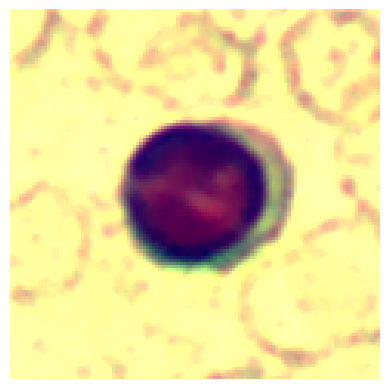

In [13]:
img_paths = []
for img in sorted(os.listdir('/kaggle/input/data-1/content/images')):
    img_path = os.path.join('/kaggle/input/data-1/content/images', img)
    img_paths.append(img_path)

print(f"Sample Paths for Images: {img_paths[:2]}")

mask_paths = []
for mask in sorted(os.listdir('/kaggle/input/data-1/content/masks')):
    mask_path = os.path.join('/kaggle/input/data-1/content/masks', mask)
    mask_paths.append(mask_path)

print(f"Sample Paths for Masks: {mask_paths[:2]}")

test_img = Image.open(img_paths[0])

plt.imshow(test_img)
plt.axis('off')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
# 7:2:1 | Train:Test:Eval

X_train, X_test, Y_train, Y_test = train_test_split(img_paths, mask_paths, test_size=0.30, random_state=42)
X_valid, X_test, Y_valid, Y_test = train_test_split(X_test, Y_test, test_size=0.33, random_state=42)

In [15]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.to(torch.float32))
])

class WBC_Dataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        feature_img = Image.open(self.x[idx])
        mask_img = Image.open(self.y[idx])
        
        feature = self.transform(feature_img)
        label = self.transform(mask_img)

        return {
            "input_ids": feature,
            "labels": label,
        }


In [16]:
train_set = WBC_Dataset(
    X_train,
    Y_train,
)

test_set = WBC_Dataset(
    X_test,
    Y_test,
)

eval_set = WBC_Dataset(
    X_valid,
    Y_valid,
)

# **Train**

In [17]:
from huggingface_hub import login

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HUGGINGFACE_TOKEN = user_secrets.get_secret("HF_TOKEN")

# Login to Hugging Face
login(HUGGINGFACE_TOKEN)

In [18]:
def dice_coefficient(preds, targets, smooth=1e-6):
    preds = torch.softmax(preds, dim=1)
    preds = preds.argmax(dim=1).float()
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(1,2))
    union = preds.sum(dim=(1,2)) + targets.sum(dim=(1,2))
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean()

def iou_score(preds, targets, smooth=1e-6):
    preds = torch.softmax(preds, dim=1)
    preds = preds.argmax(dim=1).float()
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(1,2))
    union = preds.sum(dim=(1,2)) + targets.sum(dim=(1,2)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

def precision_score(preds, targets, smooth=1e-6):
    preds = torch.softmax(preds, dim=1)
    preds = preds.argmax(dim=1).float()
    targets = targets.float()
    tp = (preds * targets).sum(dim=(1,2))
    fp = (preds * (1 - targets)).sum(dim=(1,2))
    precision = (tp + smooth) / (tp + fp + smooth)
    return precision.mean()

def recall_score(preds, targets, smooth=1e-6):
    preds = torch.softmax(preds, dim=1)
    preds = preds.argmax(dim=1).float()
    targets = targets.float()
    tp = (preds * targets).sum(dim=(1,2))
    fn = ((1 - preds) * targets).sum(dim=(1,2))
    recall = (tp + smooth) / (tp + fn + smooth)
    return recall.mean()

In [19]:
from transformers import PreTrainedModel, PretrainedConfig

class OscillatoryNeuronConfig(PretrainedConfig):
    model_type = "UNetOscillatoryNeuron"

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

class OscillatoryNeuronModel(PreTrainedModel):
    config_class = OscillatoryNeuronConfig

    def __init__(self, config):
        super().__init__(config)
        self.model = UNetOscillatoryNeuron()

    def forward(self, input_ids, labels=None):
        c_f, x_f = self.model(input_ids)
        
        metrics = {}
        loss = None
        if labels is not None:
            criterion = nn.CrossEntropyLoss()
            loss = criterion(c_f, labels.squeeze(1).long())
            metrics["dice"] = dice_coefficient(c_f, labels.squeeze(1))
            metrics["iou"] = iou_score(c_f, labels.squeeze(1))
            metrics["precision"] = precision_score(c_f, labels.squeeze(1))
            metrics["recall"] = recall_score(c_f, labels.squeeze(1))

        return {"loss": loss, "logits": c_f, "Oscillator": x_f,
                "Dice": metrics["dice"],
                "IoU": metrics["iou"],
                "Precision": metrics["precision"],
                "Recall": metrics["recall"]} if loss is not None else {"logits": c_f}

2025-05-06 14:10:50.063219: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746540650.296626      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746540650.363835      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [20]:
def compute_metrics(eval_pred):

    predictions = eval_pred.predictions
    labels = eval_pred.label_ids
    

    if isinstance(predictions, tuple):
        logits = predictions[0]
    elif isinstance(predictions, dict):
        logits = predictions["logits"]
    else:
        logits = predictions
    
    if isinstance(logits, np.ndarray):
        logits = torch.from_numpy(logits)
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels)
        
    # Calculate metrics
    dice = dice_coefficient(logits, labels.squeeze(1))
    iou = iou_score(logits, labels.squeeze(1))
    precision = precision_score(logits, labels.squeeze(1))
    recall = recall_score(logits, labels.squeeze(1))
    
    # Return metrics as a dictionary
    return {
        "dice": dice.item() if hasattr(dice, "item") else dice,
        "iou": iou.item() if hasattr(iou, "item") else iou,
        "precision": precision.item() if hasattr(precision, "item") else precision,
        "recall": recall.item() if hasattr(recall, "item") else recall
    }

class MetricsCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is not None:
            for key, value in metrics.items():
                if key.startswith("eval_"):
                    print(f"{key}: {value:.4f}")

In [21]:
from transformers import Trainer, TrainingArguments
from transformers import get_scheduler
import warnings

warnings.filterwarnings(
    "ignore",
    message="Was asked to gather along dimension 0, but all input tensors were scalars",
    category=UserWarning
)

torch.cuda.amp
torch.cuda.empty_cache()

training_args = TrainingArguments(
    output_dir="./UNetOscillatoryNeuron",
    learning_rate = 0.001,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    logging_dir="./logs",
    logging_steps=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=50,
    weight_decay=0.0005,
    warmup_ratio = 0.05,
    report_to="none",
    push_to_hub=True,
    optim = 'adamw_torch',
    lr_scheduler_type="cosine",
    hub_model_id="KanWasTaken/UNetOscillatoryNeuron",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    save_total_limit = 1
)

# Initialize Model
model = OscillatoryNeuronModel(OscillatoryNeuronConfig())

trainer = Trainer(
    model=model.to(device),
    args=training_args,
    train_dataset=train_set,
    eval_dataset=eval_set,
    #callbacks=[MetricsCallback()],
    compute_metrics=compute_metrics,
)

trainer.train()

trainer.save_model("./UNetOscillatoryNeuron")

trainer.push_to_hub("KanWasTaken/UNetOscillatoryNeuron")

Epoch,Training Loss,Validation Loss,Dice,Iou,Precision,Recall
1,1.054900,1.376964,0.452476,0.294329,0.300028,0.961453
2,0.455900,0.232315,0.287638,0.172957,0.969660,0.173907
3,0.115300,0.099621,0.748661,0.607022,0.915820,0.646092
4,0.056300,0.144709,0.763887,0.626213,0.889922,0.681374
5,0.043600,0.043464,0.708610,0.558152,0.976842,0.566318
6,0.040300,0.081726,0.751662,0.610103,0.933867,0.637113
7,0.035000,0.062274,0.745060,0.602310,0.948325,0.622822
8,0.031500,0.043497,0.737095,0.592676,0.967939,0.604122
9,0.031000,0.036070,0.720154,0.572824,0.978755,0.580712
10,0.028400,0.028506,0.719760,0.571404,0.984842,0.576258


No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/KanWasTaken/UNetOscillatoryNeuron/commit/dac084747ff7e7b95ad19607a7fb857fa6f88588', commit_message='KanWasTaken/UNetOscillatoryNeuron', commit_description='', oid='dac084747ff7e7b95ad19607a7fb857fa6f88588', pr_url=None, repo_url=RepoUrl('https://huggingface.co/KanWasTaken/UNetOscillatoryNeuron', endpoint='https://huggingface.co', repo_type='model', repo_id='KanWasTaken/UNetOscillatoryNeuron'), pr_revision=None, pr_num=None)